In [1]:
# Cell 1 — Imports & Load Everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load models
with open('C:/Users/surya/Desktop/customer-marketing-ml/models/best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

with open('C:/Users/surya/Desktop/customer-marketing-ml/models/tuned_models.pkl', 'rb') as f:
    tuned_models = pickle.load(f)

with open('C:/Users/surya/Desktop/customer-marketing-ml/models/feature_columns.pkl', 'rb') as f:
    feature_columns = pickle.load(f)

# Load data
df_scaled = pd.read_csv('C:/Users/surya/Desktop/customer-marketing-ml/data/scaled_data.csv')
df_clean  = pd.read_csv('C:/Users/surya/Desktop/customer-marketing-ml/data/clustered_data.csv')

# Load results
all_results   = pd.read_csv('C:/Users/surya/Desktop/customer-marketing-ml/models/all_models_results.csv')
tuned_results = pd.read_csv('C:/Users/surya/Desktop/customer-marketing-ml/models/tuned_models_results.csv')

print("✅ Everything loaded!")
print(f"   Features: {len(feature_columns)}")

✅ Everything loaded!
   Features: 32


### Prepare data

In [2]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df_scaled[feature_columns]
y = df_scaled['Response']

X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2, random_state=42, stratify=y_resampled
)

print("✅ Data ready!")
print(f"   Test size: {X_test.shape}")

✅ Data ready!
   Test size: (761, 32)


### Final Model Leaderboard

In [3]:
leaderboard = pd.concat([all_results, tuned_results], ignore_index=True)
leaderboard = leaderboard.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
leaderboard.index += 1

print("=" * 75)
print("FINAL MODEL LEADERBOARD")
print("=" * 75)
print(leaderboard.to_string())

FINAL MODEL LEADERBOARD
                        Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
1             XGBoost (Tuned)    0.9527     0.9574  0.9474    0.9524   0.9907
2   Gradient Boosting (Tuned)    0.9488     0.9523  0.9447    0.9485   0.9901
3       Random Forest (Tuned)    0.9474     0.9381  0.9579    0.9479   0.9882
4                     XGBoost    0.9474     0.9570  0.9368    0.9468   0.9875
5               Random Forest    0.9501     0.9407  0.9605    0.9505   0.9862
6           Gradient Boosting    0.9343     0.9388  0.9289    0.9339   0.9848
7                    AdaBoost    0.8975     0.8932  0.9026    0.8979   0.9674
8         Logistic Regression    0.8922     0.9139  0.8658    0.8892   0.9566
9         K-Nearest Neighbors    0.8371     0.7678  0.9658    0.8555   0.9221
10              Decision Tree    0.8817     0.8816  0.8816    0.8816   0.8849
11                Naive Bayes    0.7057     0.7321  0.6474    0.6872   0.7814
12     Support Vector Machine    0.6675 

### Full Comparison Chart

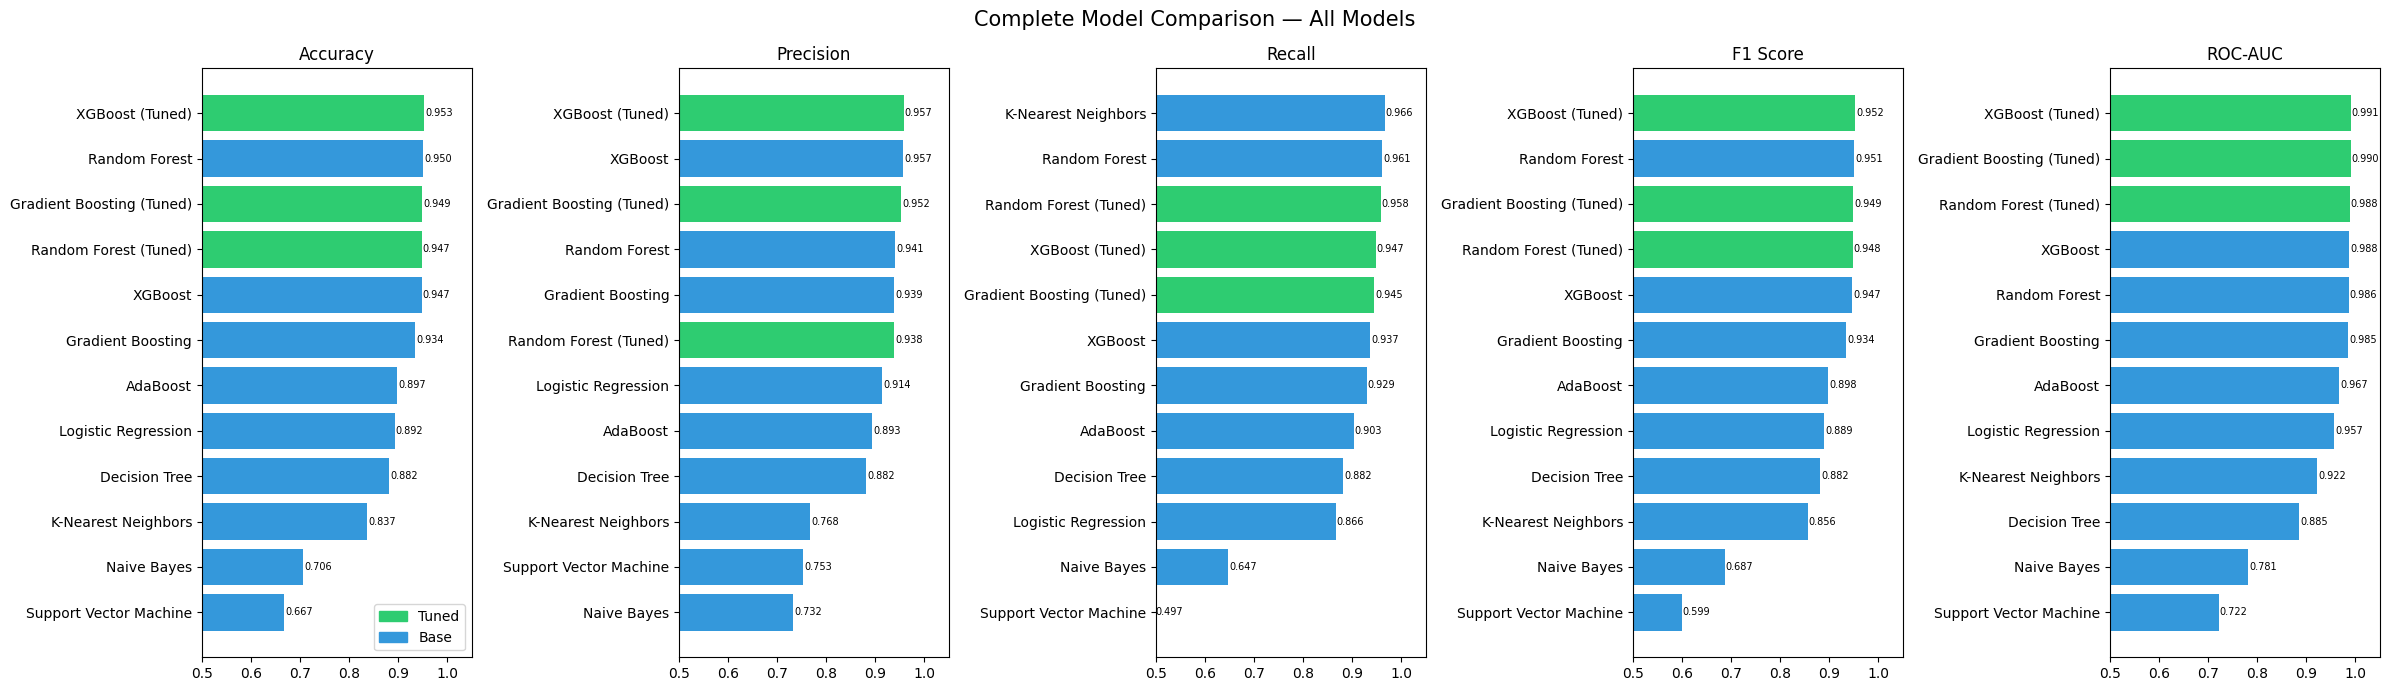

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(24, 7))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

for ax, metric in zip(axes, metrics):
    sorted_df = leaderboard.sort_values(metric, ascending=True)
    bar_colors = ['#2ECC71' if 'Tuned' in m else '#3498DB'
                  for m in sorted_df['Model']]
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=bar_colors)
    ax.set_title(metric, fontsize=12)
    ax.set_xlim(0.5, 1.05)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7)

from matplotlib.patches import Patch
legend_elements = [Patch(color='#2ECC71', label='Tuned'),
                   Patch(color='#3498DB', label='Base')]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.suptitle('Complete Model Comparison — All Models', fontsize=15)
plt.tight_layout()
plt.show()

### Feature Importance

In [5]:
importance_df = pd.DataFrame({
    'Feature'   : feature_columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("TOP 10 MOST IMPORTANT FEATURES:")
print("=" * 40)
print(importance_df.head(10).to_string(index=False))

TOP 10 MOST IMPORTANT FEATURES:
               Feature  Importance
TotalCampaignsAccepted    0.245830
        EnrollmentYear    0.104331
 Marital_Status_Single    0.050383
              Teenhome    0.046857
          AcceptedCmp2    0.036572
               Recency    0.035518
          AcceptedCmp4    0.034493
         TotalChildren    0.032020
     NumStorePurchases    0.028728
  Marital_Status_Widow    0.027458


### Plot Feature Importance

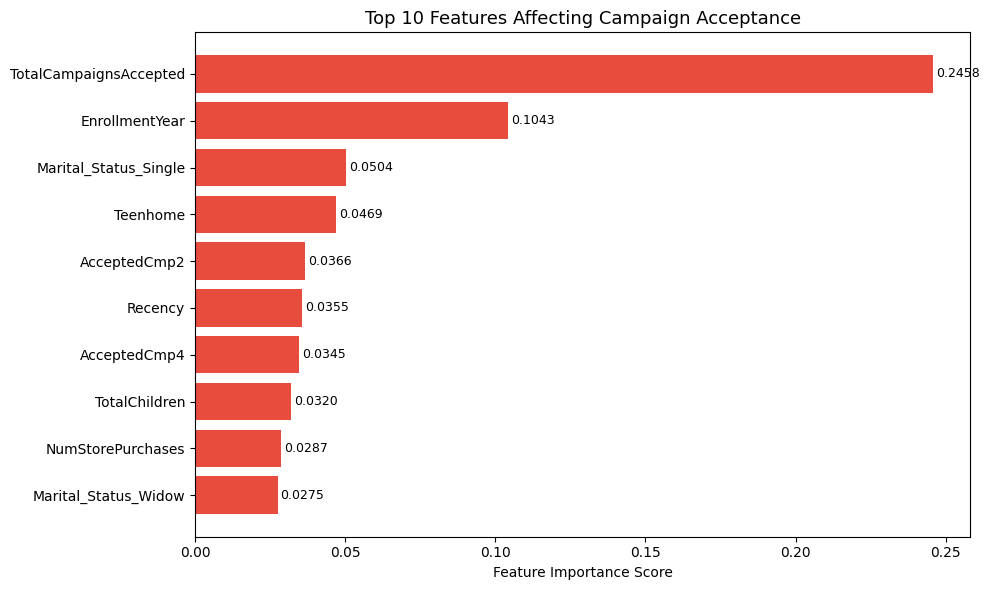

In [6]:
plt.figure(figsize=(10, 6))
top10 = importance_df.head(10)
bars = plt.barh(top10['Feature'][::-1], top10['Importance'][::-1],
                color='#E74C3C')
plt.title('Top 10 Features Affecting Campaign Acceptance', fontsize=13)
plt.xlabel('Feature Importance Score')
for bar, val in zip(bars, top10['Importance'][::-1]):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Business Insights

In [7]:
print("=" * 55)
print("BUSINESS INSIGHTS FROM FEATURE IMPORTANCE")
print("=" * 55)
print("\nTop 5 factors driving campaign acceptance:\n")
for i, row in importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:<30} importance: {row['Importance']:.4f}")

print("\nWhat this means for marketing:")
print("-" * 55)
for i, row in importance_df.head(5).iterrows():
    feat = row['Feature']
    if 'Income' in feat:
        print(f"  💰 {feat}: Higher income → more likely to accept")
    elif 'Spend' in feat or 'Mnt' in feat:
        print(f"  🛒 {feat}: Higher spenders → more likely to accept")
    elif 'Campaign' in feat or 'Accepted' in feat:
        print(f"  📢 {feat}: Past acceptors → likely to accept again")
    elif 'Recency' in feat:
        print(f"  📅 {feat}: Recent buyers → more likely to accept")
    elif 'Purchase' in feat:
        print(f"  🏪 {feat}: Frequent buyers → more likely to accept")
    else:
        print(f"  📊 {feat}: Strong predictor of campaign response")

BUSINESS INSIGHTS FROM FEATURE IMPORTANCE

Top 5 factors driving campaign acceptance:

  1. TotalCampaignsAccepted         importance: 0.2458
  2. EnrollmentYear                 importance: 0.1043
  3. Marital_Status_Single          importance: 0.0504
  4. Teenhome                       importance: 0.0469
  5. AcceptedCmp2                   importance: 0.0366

What this means for marketing:
-------------------------------------------------------
  📢 TotalCampaignsAccepted: Past acceptors → likely to accept again
  📊 EnrollmentYear: Strong predictor of campaign response
  📊 Marital_Status_Single: Strong predictor of campaign response
  📊 Teenhome: Strong predictor of campaign response
  📢 AcceptedCmp2: Past acceptors → likely to accept again


### Save Final

In [8]:
import os

os.makedirs('../models', exist_ok=True)

# Save feature importance
importance_df.to_csv('../models/feature_importance.csv', index=False)

# Save leaderboard
leaderboard.to_csv('../models/final_leaderboard.csv', index=False)

# Save scaler
from sklearn.preprocessing import StandardScaler

scale_cols = ['Income', 'Age', 'TotalSpend', 'TotalPurchases',
              'Recency', 'NumWebVisitsMonth', 'TotalChildren',
              'TotalCampaignsAccepted', 'EnrollmentYear']

df_raw = pd.read_csv('../data/cleaned_data.csv')
scaler = StandardScaler()
scaler.fit(df_raw[scale_cols])

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/scale_cols.pkl', 'wb') as f:
    pickle.dump(scale_cols, f)

print("✅ Final notebook complete!")
print("   feature_importance.csv  → top features")
print("   final_leaderboard.csv   → all model results")
print("   scaler.pkl              → fitted scaler")
print("   scale_cols.pkl          → columns to scale")

✅ Final notebook complete!
   feature_importance.csv  → top features
   final_leaderboard.csv   → all model results
   scaler.pkl              → fitted scaler
   scale_cols.pkl          → columns to scale
